In [1]:
# Import required libraries

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("Libraries Imported Successfully!")

2026-06-07 20:22:45.838884: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780863766.074375      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780863766.146789      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780863766.703217      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780863766.703342      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780863766.703345      58 computation_placer.cc:177] computation placer alr

Libraries Imported Successfully!


In [3]:
# Check dataset folder structure

dataset_path = "/kaggle/input/datasets/jordanjesudas/fabric-defect"

print("Folders in dataset:")

for item in os.listdir(dataset_path):
    print(item)

Folders in dataset:
Data Set


In [17]:
# Dataset Loading + Train/Validation/Test Split

dataset_path = "/kaggle/input/datasets/jordanjesudas/fabric-defect/Data Set"

IMG_SIZE = (128, 128)
BATCH_SIZE = 16

# Training dataset (70%)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Temporary validation + test dataset (30%)
temp_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Split remaining 30% into validation (15%) + test (15%)
val_batches = int(len(temp_dataset) * 0.5)

validation_dataset = temp_dataset.take(val_batches)
test_dataset = temp_dataset.skip(val_batches)

# Class names
class_names = train_dataset.class_names

print("Classes:", class_names)
print("Training batches:", len(train_dataset))
print("Validation batches:", len(validation_dataset))
print("Testing batches:", len(test_dataset))

Found 666 files belonging to 4 classes.
Using 467 files for training.
Found 666 files belonging to 4 classes.
Using 199 files for validation.
Classes: ['captured', 'hole', 'horizontal', 'verticle']
Training batches: 30
Validation batches: 6
Testing batches: 7


In [18]:
# Check folder structure

base_path = "/kaggle/input/datasets/jordanjesudas/fabric-defect"

for root, dirs, files in os.walk(base_path):
    print(root)
    print("Folders:", dirs)
    print("-"*50)

/kaggle/input/datasets/jordanjesudas/fabric-defect
Folders: ['Data Set']
--------------------------------------------------
/kaggle/input/datasets/jordanjesudas/fabric-defect/Data Set
Folders: ['captured', 'horizontal', 'hole', 'verticle']
--------------------------------------------------
/kaggle/input/datasets/jordanjesudas/fabric-defect/Data Set/captured
Folders: ['Hole', 'Lines']
--------------------------------------------------
/kaggle/input/datasets/jordanjesudas/fabric-defect/Data Set/captured/Hole
Folders: []
--------------------------------------------------
/kaggle/input/datasets/jordanjesudas/fabric-defect/Data Set/captured/Lines
Folders: []
--------------------------------------------------
/kaggle/input/datasets/jordanjesudas/fabric-defect/Data Set/horizontal
Folders: []
--------------------------------------------------
/kaggle/input/datasets/jordanjesudas/fabric-defect/Data Set/hole
Folders: []
--------------------------------------------------
/kaggle/input/datasets/jo

In [19]:
# Image Preprocessing + Normalization + Data Augmentation

# Normalize pixel values (0 to 1)
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
validation_dataset = validation_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

# Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

print("Preprocessing and Data Augmentation Completed!")

Preprocessing and Data Augmentation Completed!


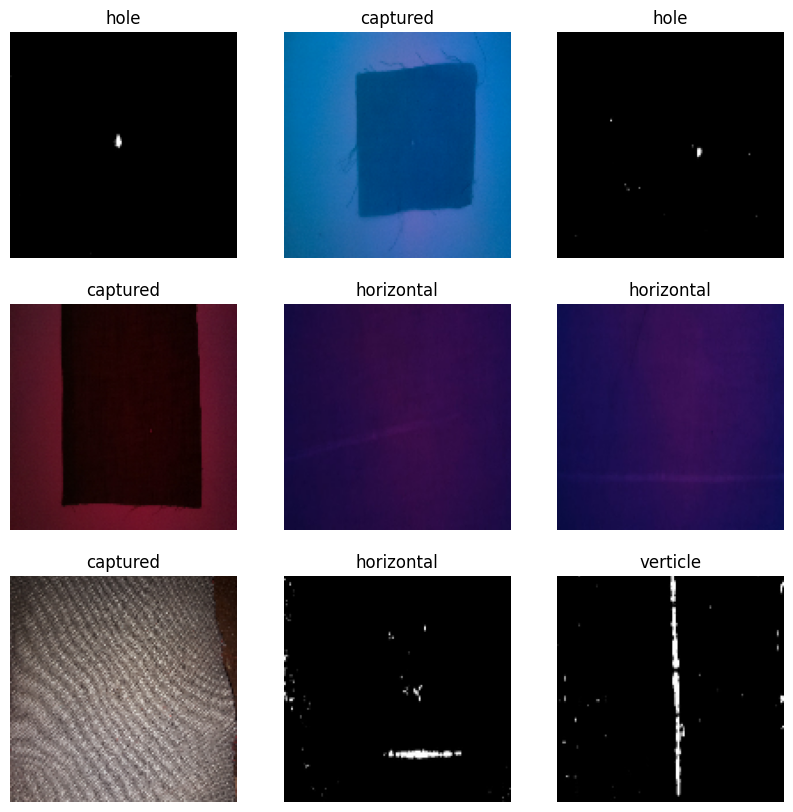

In [20]:
# Visualize Sample Images

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [21]:
# Build CNN Model (Corrected)

cnn_model = tf.keras.Sequential([

    # Input Layer
    tf.keras.layers.Input(shape=(128,128,3)),

    # Data Augmentation
    data_augmentation,

    # CNN Layers
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # Flatten Layer
    tf.keras.layers.Flatten(),

    # Dense Layers
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    # Output Layer
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

# Compile model
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show summary
cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Train CNN Model

history = cnn_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 353ms/step - accuracy: 0.5546 - loss: 1.0482 - val_accuracy: 0.7083 - val_loss: 0.9138
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 325ms/step - accuracy: 0.6767 - loss: 0.8336 - val_accuracy: 0.6979 - val_loss: 0.8361
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 330ms/step - accuracy: 0.6959 - loss: 0.7954 - val_accuracy: 0.7604 - val_loss: 0.7149
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 344ms/step - accuracy: 0.7195 - loss: 0.7365 - val_accuracy: 0.7292 - val_loss: 0.7089
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 326ms/step - accuracy: 0.7323 - loss: 0.7175 - val_accuracy: 0.7604 - val_loss: 0.7369
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 336ms/step - accuracy: 0.7259 - loss: 0.6597 - val_accuracy: 0.7188 - val_loss: 0.7093
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 339ms/step - accuracy: 0.7452 - loss: 0.6572 - val_accuracy: 0.7604 - val_loss: 0.6860
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 330ms/step - accuracy: 0.7024 - loss: 0.6372 - val_accu

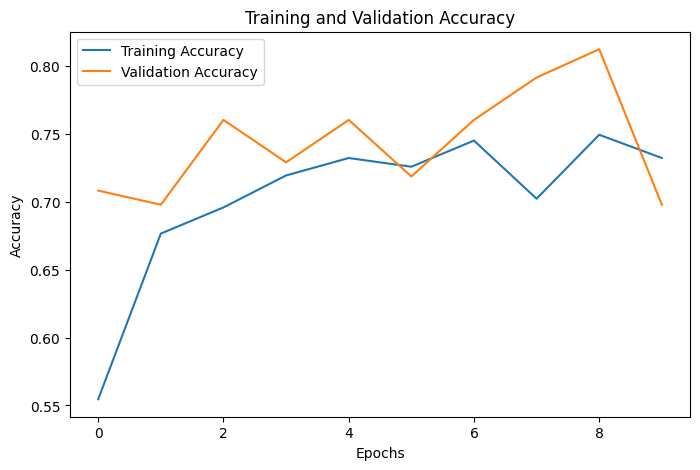

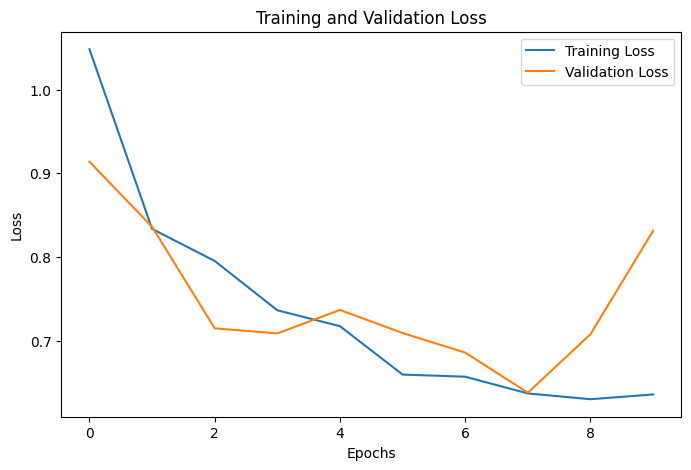

In [23]:
# Plot Accuracy and Loss Curves

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# Accuracy Graph
plt.figure(figsize=(8,5))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

# Loss Graph
plt.figure(figsize=(8,5))
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.7184 - loss: 0.7952
Test Accuracy: 0.7184466123580933
Test Loss: 0.7951737642288208
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


<Figure size 600x600 with 0 Axes>

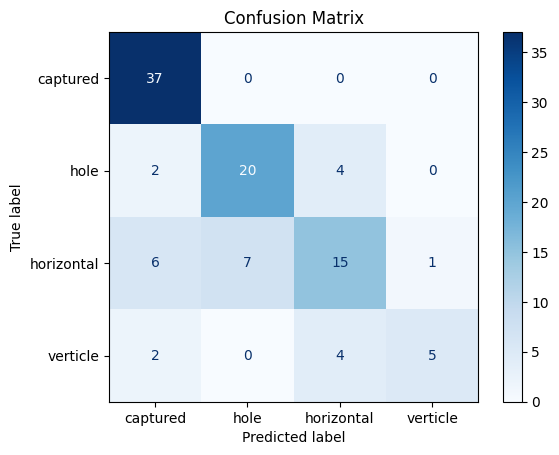

Classification Report:

              precision    recall  f1-score   support

    captured       0.79      1.00      0.88        37
        hole       0.74      0.77      0.75        26
  horizontal       0.65      0.52      0.58        29
    verticle       0.83      0.45      0.59        11

    accuracy                           0.75       103
   macro avg       0.75      0.69      0.70       103
weighted avg       0.74      0.75      0.73       103



In [24]:
# Model Evaluation + Confusion Matrix + Classification Report

# Evaluate model on test dataset
test_loss, test_accuracy = cnn_model.evaluate(test_dataset)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

# Predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = cnn_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

In [25]:
# Transfer Learning using MobileNetV2

# Load pre-trained MobileNetV2 model
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model
base_model.trainable = False

# Build Transfer Learning Model
transfer_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128,128,3)),
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

# Compile model
transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [26]:
# Train Transfer Learning Model

transfer_history = transfer_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 261ms/step - accuracy: 0.6338 - loss: 1.0053 - val_accuracy: 0.7500 - val_loss: 0.5456
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 199ms/step - accuracy: 0.7730 - loss: 0.5221 - val_accuracy: 0.7917 - val_loss: 0.4076
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 207ms/step - accuracy: 0.7923 - loss: 0.4919 - val_accuracy: 0.7812 - val_loss: 0.4892
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 198ms/step - accuracy: 0.7880 - loss: 0.4887 - val_accuracy: 0.8125 - val_loss: 0.4867
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 208ms/step - accuracy: 0.7987 - loss: 0.4575 - val_accuracy: 0.8333 - val_loss: 0.4281
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 201ms/step - accuracy: 0.7966 - loss: 0.4388 - val_accuracy: 0.8646 - val_loss: 0.3817
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 201ms/step - accuracy: 0.8223 - loss: 0.4152 - val_accuracy: 0.8229 - val_loss: 0.4311
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 210ms/step - accuracy: 0.8244 - loss: 0.3889 - val_accuracy: 0

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.7767 - loss: 0.5589 
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.8641 - loss: 0.3531
CNN Accuracy: 0.7766990065574646
MobileNetV2 Accuracy: 0.8640776872634888


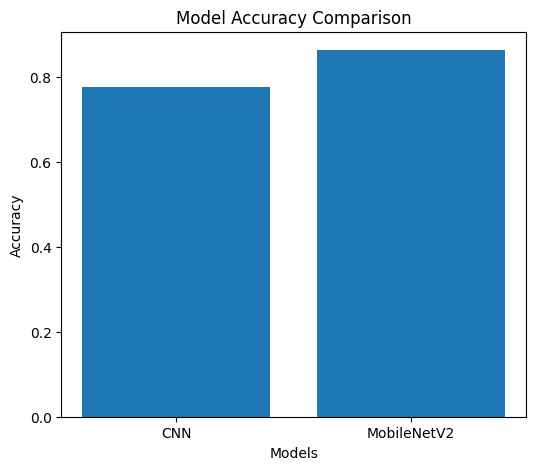

In [27]:
# Compare CNN and Transfer Learning Accuracy

# Evaluate CNN Model
cnn_loss, cnn_accuracy = cnn_model.evaluate(test_dataset)

# Evaluate MobileNetV2 Model
transfer_loss, transfer_accuracy = transfer_model.evaluate(test_dataset)

# Print Results
print("CNN Accuracy:", cnn_accuracy)
print("MobileNetV2 Accuracy:", transfer_accuracy)

# Plot Comparison Graph
models_name = ['CNN', 'MobileNetV2']
accuracy_values = [cnn_accuracy, transfer_accuracy]

plt.figure(figsize=(6,5))
plt.bar(models_name, accuracy_values)
plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.show()